In [1]:
import os
os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.18.8-hotspot"

import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import RegressionEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml import Pipeline
from sklearn.linear_model import LinearRegression as SKLinearRegression
from sklearn.ensemble import RandomForestRegressor as SKRandomForest
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

spark = (SparkSession.builder
    .master("local[*]")
    .appName("NYC_Taxi_Model_Training")
    .config("spark.driver.host", "localhost")
    .config("spark.driver.bindAddress", "localhost")
    .config("spark.ui.enabled", "false")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .getOrCreate())

spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)
print("Setup complete!")

Spark version: 4.1.1
Setup complete!


In [2]:
# Load raw data and recreate features (faster than loading huge train/test files)
DATA_PATH = r"C:\Users\MaK Tech\Documents\GitHub\nyc-taxi-bigdata\data\*.parquet"
df = spark.read.parquet(DATA_PATH)

# Clean
df_clean = df.filter(
    (F.col("fare_amount") > 0) & (F.col("fare_amount") < 500) &
    (F.col("trip_distance") > 0) & (F.col("trip_distance") < 200) &
    (F.col("total_amount") > 0) & (F.col("passenger_count") > 0) &
    (F.col("passenger_count") <= 6)
).fillna({"congestion_surcharge": 0.0, "Airport_fee": 0.0, "RatecodeID": 1})

# Feature engineering
df_feat = df_clean.withColumns({
    "pickup_hour": F.hour("tpep_pickup_datetime"),
    "pickup_dayofweek": F.dayofweek("tpep_pickup_datetime"),
    "pickup_month": F.month("tpep_pickup_datetime"),
    "trip_duration_min": (F.unix_timestamp("tpep_dropoff_datetime") - 
                          F.unix_timestamp("tpep_pickup_datetime")) / 60,
    "is_weekend": F.when(F.dayofweek("tpep_pickup_datetime").isin([1,7]), 1).otherwise(0),
    "is_rush_hour": F.when((F.hour("tpep_pickup_datetime").between(7,9)) | 
                           (F.hour("tpep_pickup_datetime").between(16,19)), 1).otherwise(0),
    "is_airport": F.when(F.col("RatecodeID") == 2, 1).otherwise(0)
}).filter((F.col("trip_duration_min") > 0) & (F.col("trip_duration_min") < 300))

# Use 5% sample for faster training (still ~1.7M records)
df_sample = df_feat.sample(fraction=0.05, seed=42)
print(f"Training sample size: {df_sample.count():,} records")
print("Data ready!")

Training sample size: 1,779,690 records
Data ready!


In [3]:
# Assemble features for regression (predict fare_amount)
feature_cols = ['trip_distance', 'passenger_count', 'PULocationID', 'DOLocationID',
                'pickup_hour', 'pickup_dayofweek', 'pickup_month',
                'trip_duration_min', 'is_weekend', 'is_rush_hour', 'is_airport',
                'congestion_surcharge', 'Airport_fee']

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")
df_ml = assembler.transform(df_sample).select("features", "fare_amount", "tip_amount", "total_amount")

# Train/Test split
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)
train_df.cache()
test_df.cache()

print(f"Features: {len(feature_cols)}")
print(f"Training: {train_df.count():,}")
print(f"Testing:  {test_df.count():,}")
print(f"Target:   fare_amount")

Features: 13
Training: 1,424,288
Testing:  355,402
Target:   fare_amount


In [4]:
print("MODEL 1: PySpark Linear Regression")
print("=" * 60)

start = time.time()
lr = LinearRegression(featuresCol="features", labelCol="fare_amount", maxIter=50, regParam=0.1)
lr_model = lr.fit(train_df)
lr_time = time.time() - start

lr_pred = lr_model.transform(test_df)
evaluator_rmse = RegressionEvaluator(labelCol="fare_amount", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="fare_amount", metricName="r2")
evaluator_mae = RegressionEvaluator(labelCol="fare_amount", metricName="mae")

lr_rmse = evaluator_rmse.evaluate(lr_pred)
lr_r2 = evaluator_r2.evaluate(lr_pred)
lr_mae = evaluator_mae.evaluate(lr_pred)

print(f"RMSE:  {lr_rmse:.4f}")
print(f"MAE:   {lr_mae:.4f}")
print(f"R²:    {lr_r2:.4f}")
print(f"Time:  {lr_time:.2f}s")

MODEL 1: PySpark Linear Regression
RMSE:  5.8638
MAE:   2.1634
R²:    0.8955
Time:  11.43s


In [5]:
print("MODEL 2: PySpark Random Forest Regressor")
print("=" * 60)

start = time.time()
rf = RandomForestRegressor(featuresCol="features", labelCol="fare_amount", 
                           numTrees=50, maxDepth=10, seed=42)
rf_model = rf.fit(train_df)
rf_time = time.time() - start

rf_pred = rf_model.transform(test_df)
rf_rmse = evaluator_rmse.evaluate(rf_pred)
rf_r2 = evaluator_r2.evaluate(rf_pred)
rf_mae = evaluator_mae.evaluate(rf_pred)

print(f"RMSE:  {rf_rmse:.4f}")
print(f"MAE:   {rf_mae:.4f}")
print(f"R²:    {rf_r2:.4f}")
print(f"Time:  {rf_time:.2f}s")

MODEL 2: PySpark Random Forest Regressor
RMSE:  4.5780
MAE:   1.1746
R²:    0.9363
Time:  214.62s


In [6]:
print("MODEL 3: PySpark Gradient Boosted Trees")
print("=" * 60)

start = time.time()
gbt = GBTRegressor(featuresCol="features", labelCol="fare_amount", 
                   maxIter=50, maxDepth=8, seed=42)
gbt_model = gbt.fit(train_df)
gbt_time = time.time() - start

gbt_pred = gbt_model.transform(test_df)
gbt_rmse = evaluator_rmse.evaluate(gbt_pred)
gbt_r2 = evaluator_r2.evaluate(gbt_pred)
gbt_mae = evaluator_mae.evaluate(gbt_pred)

print(f"RMSE:  {gbt_rmse:.4f}")
print(f"MAE:   {gbt_mae:.4f}")
print(f"R²:    {gbt_r2:.4f}")
print(f"Time:  {gbt_time:.2f}s")

MODEL 3: PySpark Gradient Boosted Trees
RMSE:  4.5282
MAE:   1.1014
R²:    0.9377
Time:  341.22s


In [7]:
print("MODEL 4: Scikit-learn Linear Regression (Baseline)")
print("=" * 60)

# Convert to pandas for sklearn
train_pd = train_df.select("features", "fare_amount").limit(100000).toPandas()
test_pd = test_df.select("features", "fare_amount").limit(25000).toPandas()

import numpy as np
X_train = np.array(train_pd['features'].tolist())
y_train = train_pd['fare_amount'].values
X_test = np.array(test_pd['features'].tolist())
y_test = test_pd['fare_amount'].values

start = time.time()
sk_lr = SKLinearRegression()
sk_lr.fit(X_train, y_train)
sk_time = time.time() - start

sk_pred = sk_lr.predict(X_test)
sk_rmse = np.sqrt(mean_squared_error(y_test, sk_pred))
sk_r2 = r2_score(y_test, sk_pred)
sk_mae = mean_absolute_error(y_test, sk_pred)

print(f"RMSE:  {sk_rmse:.4f}")
print(f"MAE:   {sk_mae:.4f}")
print(f"R²:    {sk_r2:.4f}")
print(f"Time:  {sk_time:.2f}s")
print(f"Note:  Trained on {len(X_train):,} samples (subset for sklearn)")

MODEL 4: Scikit-learn Linear Regression (Baseline)
RMSE:  3.2713
MAE:   0.7459
R²:    0.7310
Time:  0.16s
Note:  Trained on 100,000 samples (subset for sklearn)


In [8]:
print("MODEL 5: Scikit-learn Random Forest (Baseline)")
print("=" * 60)

start = time.time()
sk_rf = SKRandomForest(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
sk_rf.fit(X_train, y_train)
sk_rf_time = time.time() - start

sk_rf_pred = sk_rf.predict(X_test)
sk_rf_rmse = np.sqrt(mean_squared_error(y_test, sk_rf_pred))
sk_rf_r2 = r2_score(y_test, sk_rf_pred)
sk_rf_mae = mean_absolute_error(y_test, sk_rf_pred)

print(f"RMSE:  {sk_rf_rmse:.4f}")
print(f"MAE:   {sk_rf_mae:.4f}")
print(f"R²:    {sk_rf_r2:.4f}")
print(f"Time:  {sk_rf_time:.2f}s")

MODEL 5: Scikit-learn Random Forest (Baseline)
RMSE:  2.5863
MAE:   0.5889
R²:    0.8319
Time:  10.02s


In [9]:
print("=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)

results = {
    'Model': ['PySpark Linear Reg', 'PySpark Random Forest', 'PySpark GBT', 
              'Sklearn Linear Reg', 'Sklearn Random Forest'],
    'RMSE': [lr_rmse, rf_rmse, gbt_rmse, sk_rmse, sk_rf_rmse],
    'MAE': [lr_mae, rf_mae, gbt_mae, sk_mae, sk_rf_mae],
    'R²': [lr_r2, rf_r2, gbt_r2, sk_r2, sk_rf_r2],
    'Time (s)': [lr_time, rf_time, gbt_time, sk_time, sk_rf_time]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE')
print(results_df.to_string(index=False))

# Save results
results_df.to_csv(r"C:\Users\MaK Tech\Documents\GitHub\nyc-taxi-bigdata\data\model_results.csv", index=False)
print("\nResults saved to data/model_results.csv")

MODEL COMPARISON SUMMARY
                Model     RMSE      MAE       R²   Time (s)
Sklearn Random Forest 2.586347 0.588929 0.831862  10.021971
   Sklearn Linear Reg 3.271283 0.745925 0.731014   0.161722
          PySpark GBT 4.528180 1.101364 0.937699 341.217918
PySpark Random Forest 4.577969 1.174647 0.936322 214.616892
   PySpark Linear Reg 5.863764 2.163428 0.895528  11.425375

Results saved to data/model_results.csv


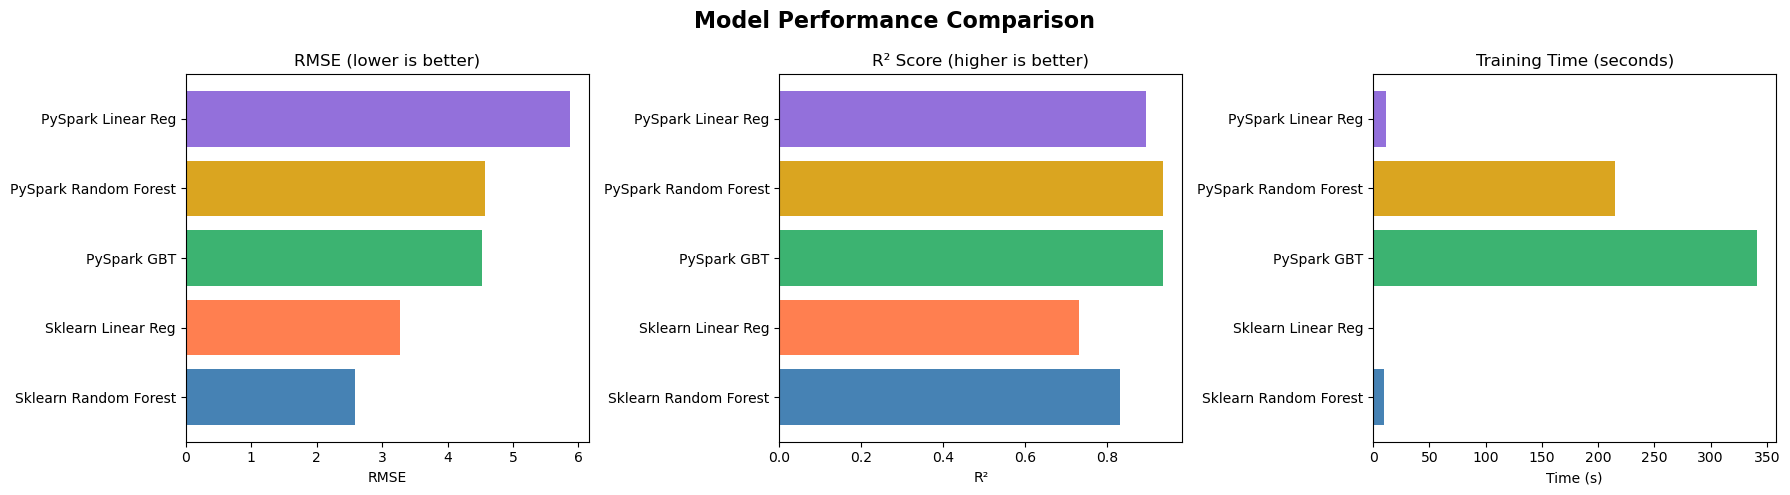

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

colors = ['steelblue', 'coral', 'mediumseagreen', 'goldenrod', 'mediumpurple']
models = results_df['Model'].tolist()

axes[0].barh(models, results_df['RMSE'], color=colors)
axes[0].set_title('RMSE (lower is better)')
axes[0].set_xlabel('RMSE')

axes[1].barh(models, results_df['R²'], color=colors)
axes[1].set_title('R² Score (higher is better)')
axes[1].set_xlabel('R²')

axes[2].barh(models, results_df['Time (s)'], color=colors)
axes[2].set_title('Training Time (seconds)')
axes[2].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

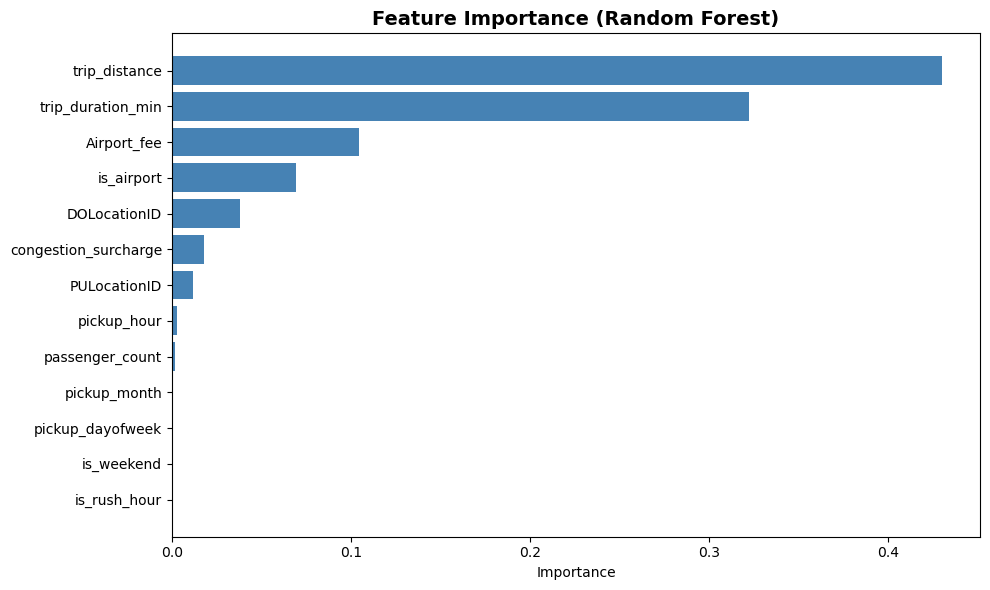

In [11]:
# Feature importance from Random Forest
importances = rf_model.featureImportances.toArray()
feat_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
feat_imp = feat_imp.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feat_imp['Feature'], feat_imp['Importance'], color='steelblue')
ax.set_title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

In [12]:
best = results_df.iloc[0]
print("=" * 60)
print("NOTEBOOK 3 COMPLETE - MODEL TRAINING")
print("=" * 60)
print(f"\nBest Model: {best['Model']}")
print(f"Best RMSE:  {best['RMSE']:.4f}")
print(f"Best R²:    {best['R²']:.4f}")
print(f"Models trained: 5 (3 PySpark + 2 Sklearn)")
print(f"\nNext: Notebook 4 - Evaluation & Scalability")

spark.stop()
print("Spark session stopped.")

NOTEBOOK 3 COMPLETE - MODEL TRAINING

Best Model: Sklearn Random Forest
Best RMSE:  2.5863
Best R²:    0.8319
Models trained: 5 (3 PySpark + 2 Sklearn)

Next: Notebook 4 - Evaluation & Scalability
Spark session stopped.
